subprocess.callで実行する場合、存在するtomlファイルを指定すればreinventは実行できる。
1. tomlファイルをsubprocess.callで編集できれば実行できる
2. tomlファイルをつくらずに実行できればなおよい

# 環境構築

reinvent4用に新しい仮想環境を構築する。  
https://github.com/MolecularAI/REINVENT4
M1 Macの場合はAnacondaよりMiniforgeがいい。



1. Clone reinvent4 repository
```bash
mkdir REINVENT4
cd REINVENT4
git clone https://github.com/MolecularAI/REINVENT4.git
```
2. create conda environment with python=3.10
```bash
conda create --name r4 python=3.10
conda activate r4
```
3. install REINVENT4 with install python script. (for me, useing mac)
```bash
# python install.py --help
python install.py mac
```
4. test the tool with help option.
```bash
reinvent --help
```

reinventの環境構築の後に下記をインストールする必要あり

```bash
pip install mols2grid
conda install rdkit pubchempy requests chembl_rewebsource_client seaborn  
```

# REINVENT4の実行

## Working Directoryとpathの設定

import libraries

In [3]:
import os
import glob
import shutil
import subprocess
from rdkit.Chem import PandasTools, Draw

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import reinvent
from reinvent.notebooks import load_tb_data, plot_scalars, get_image, create_mol_grid

from datetime import datetime

%load_ext tensorboard

#### set working directory, toml and results directories

In [52]:
# REINVENT4のインストールディレクトリ直下にworking_dirを作成
home_dir = os.path.expanduser("~")
reinvent_dir = os.path.expanduser("~/Documents/apps/REINVENT4")
wd = os.path.join(reinvent_dir, "wd") # 作業ディレクトリのパス
os.makedirs(wd, exist_ok=True) # ディレクトリが存在しない場合は作成
os.chdir(wd) # wdに移動
os.makedirs('toml', exist_ok=True) # tomlディレクトリを作成
toml_dir = os.path.join(wd, 'toml') # tomlディレクトリのパス
os.makedirs('results', exist_ok=True) # resultsディレクトリを作成
results = os.path.join(wd, 'results') # resultsディレクトリのパス
os.makedirs('input', exist_ok=True) # resultsディレクトリを作成
input = os.path.join(wd, 'input') # resultsディレクトリのパス
os.makedirs('model', exist_ok=True) # modelディレクトリを作成
model = os.path.join(wd, 'model') # modelディレクトリのパス
print(os.getcwd())
print(os.listdir())

/Users/keetane/Documents/apps/REINVENT4/wd
['toml', 'input', 'results', 'tyk2.smi', 'model', 'tb_TL']


#### set model file path

In [5]:
priors_dir = os.path.join(reinvent_dir, "priors")
reinvent = os.path.join(priors_dir, "reinvent.prior")
lib = os.path.join(priors_dir, "libinvent.prior")
link = os.path.join(priors_dir, "linkinvent.prior")
mol2mol_high = os.path.join(priors_dir, "mol2mol_high_similarity.prior")
mol2mol_med = os.path.join(priors_dir, "mol2mol_medium_similarity.prior")
mol2mol_mmp = os.path.join(priors_dir, "mol2mol_mmp.prior")
mol2mol_scaffold_generic= os.path.join(priors_dir, "mol2mol_scaffold_generic.prior")
mol2mol_scaffold = os.path.join(priors_dir, "mol2mol_scaffold.prior")
mol2mol_similarity = os.path.join(priors_dir, "mol2mol_similarity.prior")
pubchem = os.path.join(priors_dir, "pubchem_ecfp4_with_count_with_rank_reinvent4_dict_voc.prior")
reinvent

'/Users/keetane/Documents/apps/REINVENT4/priors/reinvent.prior'

## tomlファイルの更新とREINVENT4の実行

### sampling

#### 関数の定義

In [53]:
def sampling(model=reinvent, num_smiles=155, smiles_file=None, device="mps", show=False, sample_strategy=None, temperature=1.0):
    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    model_name = os.path.splitext(os.path.basename(model))[0]
    toml=f'''
    run_type = "sampling"
    device = "{device}"  # set torch device e.g. "cpu". For macOS, use "mps"
    json_out_config = "{results}/_sampling.json"  # write this TOML to JSON


    [parameters]
    model_file = "{model}"
    output_file = '{results}/{model_name}_{timestamp}.csv'  # sampled SMILES and NLL in CSV format

    num_smiles = {num_smiles}  # number of SMILES to be sampled, 1 per input SMILES
    unique_molecules = true  # if true remove all duplicatesd canonicalize smiles
    randomize_smiles = true # if true shuffle atoms in SMILES randomly
    '''
    
    if smiles_file is not None:
        toml += f'''
        smiles_file = "{smiles_file}"  # 1 compound per line
        '''

    if sample_strategy == 'beamsearch':
        toml += f'''
        sample_strategy = "beamsearch"  # multinomial or beamsearch (deterministic)
        '''
    elif sample_strategy == 'multinomial':
        toml += f'''
        sample_strategy = "multinomial"  # multinomial or beamsearch (deterministic)
        temperature = {temperature} # temperature in multinomial sampling
        '''
    else:
        pass

    toml_path = f"{toml_dir}/sampling.toml"

    with open(toml_path, "w") as f:
        f.write(toml)

    # Run REINVENT4
    subprocess.call([
        f"{home_dir}/miniforge3/envs/r4/bin/reinvent",
         '-l', f'{results}/log/{model_name}_sampling_{timestamp}.log', 
         toml_path
         ])

    # Draw the sampled molecules
    if show==True:
        df = pd.read_csv(f'{results}/{model_name}_{timestamp}.csv')
        PandasTools.AddMoleculeColumnToFrame(df, smilesCol='SMILES', molCol='Mol')
        img = Draw.MolsToGridImage(df.sample(30).Mol.tolist(), molsPerRow=5, subImgSize=(300,200), legends=df.NLL.astype(str).tolist())
        return img


サンプリングの実行

In [54]:
# sampling(model=link, smiles_file=f'{input}/warheads.smi')
sampling(model=reinvent)

results directoryのファイル名に番号付

In [55]:
# 対象のファイルを取得
csv = glob.glob(results +"/*.csv")

# 順番に番号を振って dict に格納（1からスタート）
csv_dict = {i+1: f for i, f in enumerate(csv)}

# 結果を表示
for idx, path in csv_dict.items():
    print(f"{idx}: {path}")


1: /Users/keetane/Documents/apps/REINVENT4/wd/results/valid.csv
2: /Users/keetane/Documents/apps/REINVENT4/wd/results/train.csv


生成した構造の表示

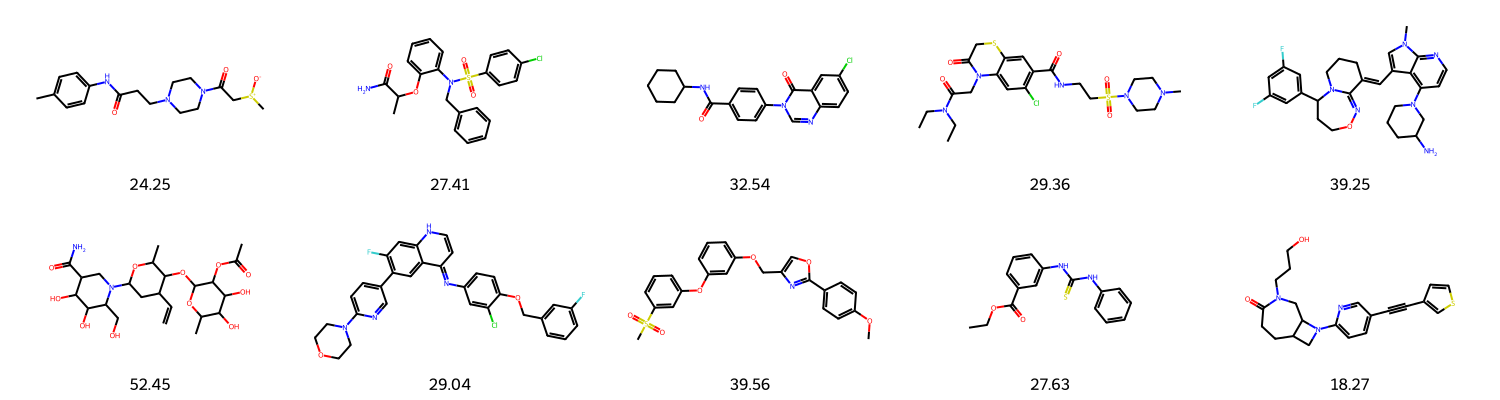

In [31]:
num = 4
csv_name =csv_dict[int(num)] 
img = pd.read_csv(csv_name)
PandasTools.AddMoleculeColumnToFrame(img, smilesCol='SMILES', molCol='Mol')
Draw.MolsToGridImage(img.sample(10).Mol.tolist(), molsPerRow=5, subImgSize=(300,200), legends=img.NLL.astype(str).tolist())

## 起点化合物からLivInvent or mol2mol
ある起点化合物についてRecapで分解し、部分構造を生成させる

#### 構造の取得と確認
pubchemからRuxolitinibの構造を取得する

In [8]:
import pubchempy as pcp
from rdkit import Chem
from rdkit.Chem import AllChem, Draw, Recap

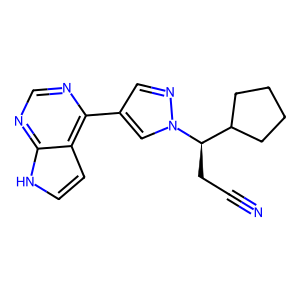

In [9]:
smiles = pcp.get_compounds('ruxolitinib', 'name')[0].isomeric_smiles
Draw.MolToImage(Chem.MolFromSmiles(smiles), size=(300, 300))

SMILESを保存

In [14]:
# ファイルに保存（1行：SMILES + タブ + 化合物名）
with open(f'{input}/ruxolitinib.smi', 'w') as f:
    f.write(f"{smiles}\truxolitinib\n")

import pandas as pd
pd.read_csv(f'{input}/ruxolitinib.smi', sep='\t', header=None, names=['SMILES', 'Name'])

,SMILES,Name
0,C1CCC(C1)[C@@H](CC#N)N2C=C(C=N2)C3=C4C=CNC4=NC=N3,ruxolitinib


Recapで1step分解

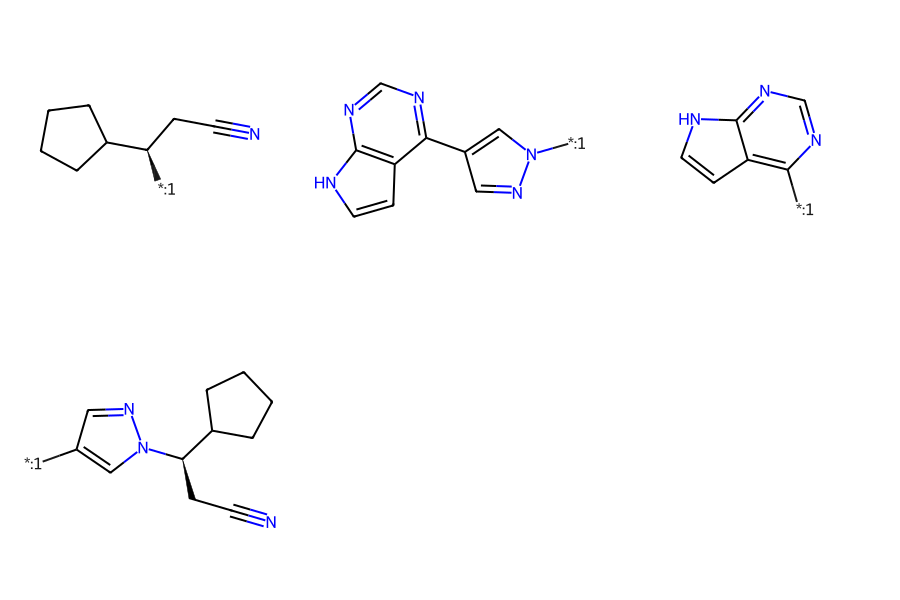

In [10]:
from rdkit import Chem
from rdkit.Chem import Recap

mol = Chem.MolFromSmiles(smiles)
recap_tree = Recap.RecapDecompose(mol)
modified_smiles = []
modified_mols = []
# modified_mols.append(mol)  # 元の分子も追加

# ダミー原子にatom map番号を付ける関数
def relabel_dummy_atoms(mol, map_num=1):
    """mol内のすべてのダミー原子(*)にatom map番号を付ける → [*:1]形式に"""
    rw_mol = Chem.RWMol(mol)
    for atom in rw_mol.GetAtoms():
        if atom.GetAtomicNum() == 0:  # dummy atom (*)
            atom.SetAtomMapNum(map_num)
    return rw_mol.GetMol()

# 分子を1stepだけ分解し、ラベルを変換
for smiles, node in recap_tree.children.items():
    mol = node.mol
    modified = relabel_dummy_atoms(mol, map_num=1)
    modified_mols.append(modified)
    modified_smiles.append(Chem.MolToSmiles(modified))

# --- 💾 decomposed.smi に保存 ---
with open(f"{input}/ruxolitinib_decomposed.smi", "w") as f:
    for i in modified_smiles:
        # mapped_mol = relabel_dummy_atoms(mol_frag, map_num=1)
        # mapped_smiles = Chem.MolToSmiles(mapped_mol)
        f.write(f"{i}\n")

# 構造確認
Draw.MolsToGridImage(modified_mols, molsPerRow=3, subImgSize=(300,300))

# decomped_smiles = []
# decomped_mols = []
# decomped_mols.append(mol)  # 元の分子も追加
# decomped_smiles.append("Original Molecule")

# for key, node in recap_tree.children.items():
#     decomped_smiles.append(key)
#     decomped_mols.append(Chem.MolFromSmiles(key))

# Draw.MolsToGridImage(decomped_mols, legends=decomped_smiles, molsPerRow=3, subImgSize=(300,300))

3番目の構造を起点にLibInvent

In [11]:
with open(f"{input}/parent.smi", "w") as f:
    f.write(modified_smiles[2])
pd.read_csv(f"{input}/parent.smi", sep='\t', header=None, names=['SMILES'])

,SMILES
0,c1nc([*:1])c2cc[nH]c2n1


In [12]:
sampling(model=lib, smiles_file=f'{input}/parent.smi')

python(39646) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


生成した構造を確認

In [13]:
# 対象のファイルを取得
csv = glob.glob(results +"/*.csv")

# 順番に番号を振って dict に格納（1からスタート）
csv_dict = {i+1: f for i, f in enumerate(csv)}

# 結果を表示
for idx, path in csv_dict.items():
    print(f"{idx}: {path}")


1: /Users/keetane/Documents/apps/REINVENT4/wd/results/libinvent_20250423_215208.csv
2: /Users/keetane/Documents/apps/REINVENT4/wd/results/reinvent_20250410_214817.csv
3: /Users/keetane/Documents/apps/REINVENT4/wd/results/libinvent_20250410_215632.csv
4: /Users/keetane/Documents/apps/REINVENT4/wd/results/reinvent_20250423_214958.csv


生成した構造の表示

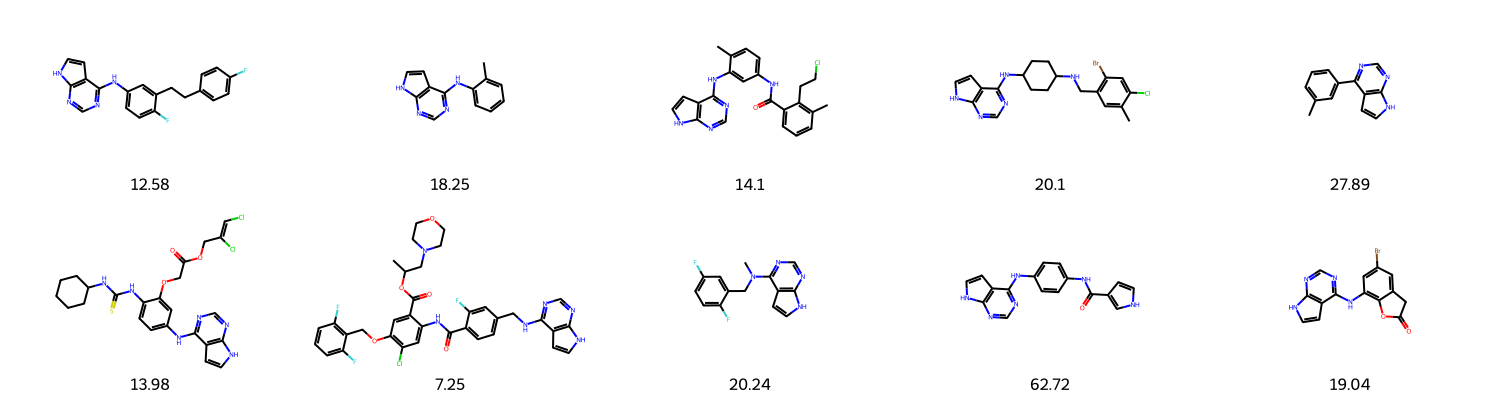

In [15]:
csv_name =csv_dict[1]
img = pd.read_csv(csv_name)
PandasTools.AddMoleculeColumnToFrame(img, smilesCol='SMILES', molCol='Mol')
Draw.MolsToGridImage(img.sample(10).Mol.tolist(), molsPerRow=5, subImgSize=(300,200), legends=img.NLL.astype(str).tolist())

# Transfer Learning

## APIで化合物情報を取得

ライブラリのimport

In [59]:
# https://github.com/chembl/notebooks/blob/main/ChEMBL_webresource_client_examples.ipynb
from chembl_webresource_client.new_client import new_client
from IPython.display import SVG
import requests
import pandas as pd
from rdkit.Chem.Draw import IPythonConsole
from rdkit.Chem import AllChem, PandasTools, rdRGroupDecomposition, Descriptors, Draw, Descriptors3D, rdMolDescriptors
from rdkit import DataStructs, rdBase, Chem

import platform
print('python version: ' + platform.python_version())
print(f'rdkit version: {rdBase.rdkitVersion}')

python version: 3.10.17
rdkit version: 2024.09.6


### UniProt IDからTarget ChEMBL IDを検索

In [60]:
uniprot_id = 'P00533' # EGFR
target = new_client.target.get(
    target_components__accession=uniprot_id
    ).only(
        'target_chembl_id', 
        'organism', 
        'pref_name', 
        'target_type'
        )
df = pd.DataFrame.from_records(target)
df

,organism,pref_name,target_chembl_id,target_type
0,Homo sapiens,Epidermal growth factor receptor erbB1,CHEMBL203,SINGLE PROTEIN
1,Homo sapiens,Epidermal growth factor receptor erbB1,CHEMBL203,SINGLE PROTEIN
2,Homo sapiens,Epidermal growth factor receptor and ErbB2 (HE...,CHEMBL2111431,PROTEIN FAMILY
3,Homo sapiens,Epidermal growth factor receptor,CHEMBL2363049,PROTEIN FAMILY
4,Homo sapiens,MER intracellular domain/EGFR extracellular do...,CHEMBL3137284,CHIMERIC PROTEIN
5,Homo sapiens,Protein cereblon/Epidermal growth factor receptor,CHEMBL4523680,PROTEIN-PROTEIN INTERACTION
6,Homo sapiens,EGFR/PPP1CA,CHEMBL4523747,PROTEIN-PROTEIN INTERACTION
7,Homo sapiens,VHL/EGFR,CHEMBL4523998,PROTEIN-PROTEIN INTERACTION
8,Homo sapiens,Baculoviral IAP repeat-containing protein 2/Ep...,CHEMBL4802031,PROTEIN-PROTEIN INTERACTION
9,Homo sapiens,CCN2-EGFR,CHEMBL5465557,PROTEIN-PROTEIN INTERACTION


### ChEMBL IDからデータを取得し、脱塩してファイルを保存

In [108]:
import pandas as pd
from chembl_webresource_client.new_client import new_client
from rdkit import Chem
from rdkit.Chem import Descriptors

ChEMBL_id = 'CHEMBL2363049'

# 1. 活性のある化合物のデータ取得
activities = new_client.activity.filter(
    target_chembl_id__in=ChEMBL_id,
    pchembl_value__gte=5,
    assay_type='B',
).only([
    'molecule_chembl_id',
    'molecule_pref_name',
    'target_pref_name',
    'parent_molecule_chembl_id',
    'pchembl_value',
    'canonical_smiles',
    'document_chembl_id',
    'document_journal',
])
df = pd.DataFrame.from_records(activities)

# 2. 主成分（分子量最大の構成要素）を抽出する関数
def extract_main_component(smiles):
    try:
        fragments = smiles.split('.')
        max_mol = None
        max_weight = -1
        for frag in fragments:
            mol = Chem.MolFromSmiles(frag)
            if mol is None:
                continue
            mw = Descriptors.MolWt(mol)
            if mw > max_weight:
                max_mol = mol
                max_weight = mw
        if max_mol:
            return Chem.MolToSmiles(max_mol, isomericSmiles=False)
        else:
            return None
    except Exception as e:
        print(f"Error splitting SMILES: {smiles} -> {e}")
        return None

# 3. 分子量最大部分のSMILES抽出 → 標準化処理
df["smiles"] = df["canonical_smiles"].apply(extract_main_component)

# 4. 無効なエントリを削除
df_clean = df.dropna(subset=["smiles"])

# 5. 保存
df_clean[['smiles', 'pchembl_value']].to_csv(f'input/{ChEMBL_id}.smi', sep='\t', index=False)
df_clean.to_csv(f'input/{ChEMBL_id}.csv', sep='\t', index=False)

print(f"Saved {len(df_clean)} ligands with largest fragment SMILES to input/{ChEMBL_id}.csv and input/{ChEMBL_id}.smi")


Saved 84 ligands with largest fragment SMILES to input/CHEMBL2363049.csv and input/CHEMBL2363049.smi


構造の確認

In [109]:
df = pd.read_csv(f'input/{ChEMBL_id}.csv', 
            sep='\t', 
            header=0, 
            # index_col=0,
            encoding='utf-8',
            )
df.head(2)

,canonical_smiles,document_chembl_id,document_journal,molecule_chembl_id,molecule_pref_name,parent_molecule_chembl_id,pchembl_value,target_pref_name,value,smiles
0,Cc1cc(Nc2nc3cccc(Cl)c3o2)ccc1-c1nn([C@H]2CC[C@...,CHEMBL1255185,Bioorg Med Chem Lett,CHEMBL1256436,NaN,CHEMBL1256436,6.28,Epidermal growth factor receptor,530.0,Cc1cc(Nc2nc3cccc(Cl)c3o2)ccc1-c1nn(C2CCC(N3CCN...
1,Cc1cc(Nc2nc3cccc(Cl)c3o2)ccc1-c1nn([C@H]2CC[C@...,CHEMBL1255185,Bioorg Med Chem Lett,CHEMBL1256436,NaN,CHEMBL1256436,6.28,Epidermal growth factor receptor,530.0,Cc1cc(Nc2nc3cccc(Cl)c3o2)ccc1-c1nn(C2CCC(N3CCN...


構造を確認

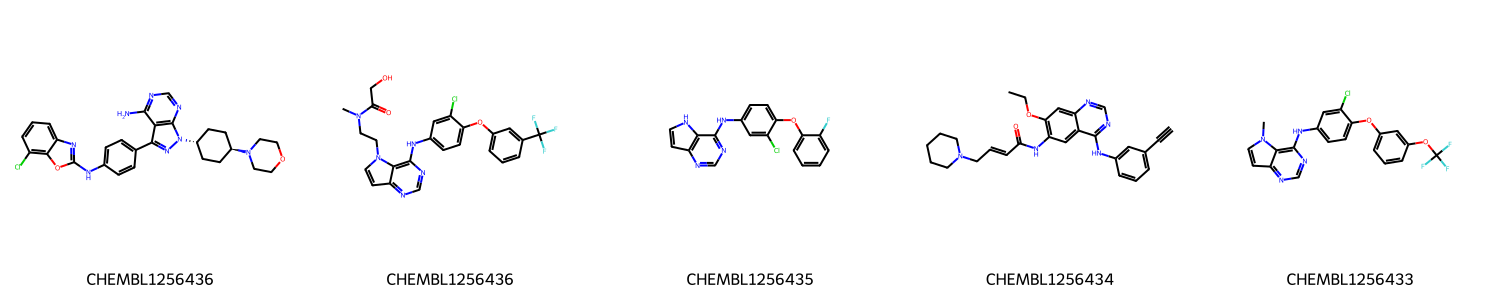

In [110]:
# 5化合物をランダムサンプリング
Draw.MolsToGridImage(
    [Chem.MolFromSmiles(x) for x in df.canonical_smiles.sample(5)], 
    legends=df['molecule_chembl_id'].tolist(), 
    molsPerRow=5, 
    subImgSize=(300, 300)
)

## Transfer Learning

関数

In [111]:
def TL(model=reinvent, input=None, valid=None, device="mps", show=False, ):
    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    model_name = os.path.splitext(os.path.basename(model))[0]

    if valid is None:
        valid = input
    
    toml=f'''
    run_type = "transfer_learning"
    device = "{device}"  # set torch device e.g. "cpu". For macOS, use "mps"
    tb_logdir = "tb_TL"  # name of the TensorBoard logging directory
    json_out_config = "{results}/json_transfer_learning.json"  # write this TOML to JSON


    [parameters]
    num_epochs = 3  # number of steps to run
    save_every_n_epochs = 3  # save checkpoint model file very N steps
    batch_size = 50
    num_refs = 100  # number of reference molecules randomly chosen for similarity
                    # set this to zero for large datasets (>200 molecules)!
    sample_batch_size = 100  # number of sampled molecules to compute sample loss
    # Uncomment one of the comment blocks below.  Each generator needs a model
    # file and possibly a SMILES file with seed structures.

    input_model_file = "{model}"
    smiles_file = "{input}"  # read 1st column
    output_model_file = '{model}/TL_{model_name}_{timestamp}.model'  # sampled SMILES and NLL in CSV format
    validation_smiles_file = "{valid}"  # read 1st column
    
    # Define the type of similarity and its parameters
    pairs.type = "tanimoto"
    pairs.upper_threshold = 1.0
    pairs.lower_threshold = 0.7
    pairs.min_cardinality = 1
    pairs.max_cardinality = 199

    '''

    toml_path = f"{wd}/toml/TL.toml"

    with open(toml_path, "w") as f:
        f.write(toml)

    # Run REINVENT4
    subprocess.call([
        f"{home_dir}/miniforge3/envs/r4/bin/reinvent",
         '-l', f'{model}/log/{model_name}_sampling_{timestamp}.log', 
         toml_path
         ])

    # Draw the sampled molecules
    if show==True:
        df = pd.read_csv(f'{results}/{model_name}_{timestamp}.csv')
        PandasTools.AddMoleculeColumnToFrame(df, smilesCol='SMILES', molCol='Mol')
        img = Draw.MolsToGridImage(df.sample(30).Mol.tolist(), molsPerRow=5, subImgSize=(300,200), legends=df.NLL.astype(str).tolist())
        return img


Transfer learningの実行

In [ ]:
import os
from datetime import datetime
import subprocess

def TL(model=reinvent, input=None, valid=None, device="mps", show=False):
    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    model_name = os.path.splitext(os.path.basename(model))[0]

    if valid is None:
        valid = input

    model_dir = os.path.dirname(model)  # ✅ モデルファイルの親ディレクトリを取得
    log_dir = os.path.join(model_dir, "log")
    os.makedirs(log_dir, exist_ok=True)

    output_model_path = os.path.join(model_dir, f"TL_{model_name}_{timestamp}.model")
    log_file = os.path.join(log_dir, f"{model_name}_sampling_{timestamp}.log")

    toml = f'''
    run_type = "transfer_learning"
    device = "{device}"
    tb_logdir = "tb_TL"
    json_out_config = "{results}/json_transfer_learning.json"

    [parameters]
    num_epochs = 3
    save_every_n_epochs = 3
    batch_size = 50
    num_refs = 100
    sample_batch_size = 100

    input_model_file = "{model}"
    smiles_file = "{input}"
    output_model_file = "{output_model_path}"
    validation_smiles_file = "{valid}"

    #[pairs]
    #type = "tanimoto"
    #upper_threshold = 1.0
    #lower_threshold = 0.7
    #min_cardinality = 1
    #max_cardinality = 199
    '''

    toml_path = f"{wd}/toml/TL.toml"
    os.makedirs(os.path.dirname(toml_path), exist_ok=True)

    with open(toml_path, "w") as f:
        f.write(toml)

    subprocess.call([
        f"{home_dir}/miniforge3/envs/r4/bin/reinvent",
        '-l', log_file,
        toml_path
    ])


In [ ]:
TL(model=reinvent, input='input/CHEMBL2363049.smi')

Traceback (most recent call last):
  File "/Users/keetane/miniforge3/envs/r4/bin/reinvent", line 8, in <module>
    sys.exit(main_script())
  File "/Users/keetane/Documents/apps/REINVENT4/reinvent/Reinvent.py", line 195, in main_script
    main(args)
  File "/Users/keetane/Documents/apps/REINVENT4/reinvent/Reinvent.py", line 49, in main
    logger = setup_logger(
  File "/Users/keetane/Documents/apps/REINVENT4/reinvent/utils/logmon.py", line 98, in setup_logger
    handler = logging.FileHandler(filename, mode="w+")
  File "/Users/keetane/miniforge3/envs/r4/lib/python3.10/logging/__init__.py", line 1169, in __init__
    StreamHandler.__init__(self, self._open())
  File "/Users/keetane/miniforge3/envs/r4/lib/python3.10/logging/__init__.py", line 1201, in _open
    return open_func(self.baseFilename, self.mode,
NotADirectoryError: [Errno 20] Not a directory: '/Users/keetane/Documents/apps/REINVENT4/priors/reinvent.prior/log/reinvent_sampling_20250429_224953.log'


In [ ]:
def sampling(model=reinvent, num_smiles=155, smiles_file=None, device="mps", show=False, sample_strategy=None, temperature=1.0):
    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    model_name = os.path.splitext(os.path.basename(model))[0]

    # Define output model and log file paths
    log_dir = f"{model}/log"
    os.makedirs(log_dir, exist_ok=True)  # ✅ ログ用ディレクトリがなければ作成

    output_model_path = f"{model}/TL_{model_name}_{timestamp}.model"
    log_file = f'{log_dir}/{model_name}_sampling_{timestamp}.log'

    toml=f'''
    run_type = "sampling"
    device = "{device}"  # set torch device e.g. "cpu". For macOS, use "mps"
    json_out_config = "{results}/_sampling.json"  # write this TOML to JSON


    [parameters]
    model_file = "{model}"
    output_file = '{results}/{model_name}_{timestamp}.csv'  # sampled SMILES and NLL in CSV format

    num_smiles = {num_smiles}  # number of SMILES to be sampled, 1 per input SMILES
    unique_molecules = true  # if true remove all duplicatesd canonicalize smiles
    randomize_smiles = true # if true shuffle atoms in SMILES randomly
    '''
    
    if smiles_file is not None:
        toml += f'''
        smiles_file = "{smiles_file}"  # 1 compound per line
        '''

    if sample_strategy == 'beamsearch':
        toml += f'''
        sample_strategy = "beamsearch"  # multinomial or beamsearch (deterministic)
        '''
    elif sample_strategy == 'multinomial':
        toml += f'''
        sample_strategy = "multinomial"  # multinomial or beamsearch (deterministic)
        temperature = {temperature} # temperature in multinomial sampling
        '''
    else:
        pass

    toml_path = f"{toml_dir}/sampling.toml"

    with open(toml_path, "w") as f:
        f.write(toml)

    # Run REINVENT4
    subprocess.call([
        f"{home_dir}/miniforge3/envs/r4/bin/reinvent",
         '-l', f'{results}/log/{model_name}_sampling_{timestamp}.log', 
         toml_path
         ])

    # Draw the sampled molecules
    if show==True:
        df = pd.read_csv(f'{results}/{model_name}_{timestamp}.csv')
        PandasTools.AddMoleculeColumnToFrame(df, smilesCol='SMILES', molCol='Mol')
        img = Draw.MolsToGridImage(df.sample(30).Mol.tolist(), molsPerRow=5, subImgSize=(300,200), legends=df.NLL.astype(str).tolist())
        return img


TLのmodelを使ってsampling

In [60]:
%ls ~/Documents/apps/REINVENT4/wd/results/TL_mol2mol_scaffold_generic_20231031_153028.model

python(66773) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


ls: /Users/keetane/Documents/apps/REINVENT4/wd/results/TL_mol2mol_scaffold_generic_20231031_153028.model: No such file or directory


In [61]:
sampling(model=f'{results}/TL_mol2mol_scaffold_generic_20250423_231613.model')
# sampling(model=reinvent)

python(66793) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Traceback (most recent call last):
  File "/Users/keetane/opt/anaconda3/envs/reinevent/bin/reinvent", line 8, in <module>
    sys.exit(main_script())
  File "/Users/keetane/opt/anaconda3/envs/reinevent/lib/python3.10/site-packages/reinvent/Reinvent.py", line 195, in main_script
    main(args)
  File "/Users/keetane/opt/anaconda3/envs/reinevent/lib/python3.10/site-packages/reinvent/Reinvent.py", line 164, in main
    runner(
  File "/Users/keetane/opt/anaconda3/envs/reinevent/lib/python3.10/site-packages/reinvent/runmodes/samplers/run_sampling.py", line 97, in run_sampling
    sampled = sampler.sample(input_smilies)
  File "/Users/keetane/opt/anaconda3/envs/reinevent/lib/python3.10/site-packages/reinvent/runmodes/samplers/mol2mol.py", line 33, in sample
    smilies = [conversions.convert_to_standardized_smiles(smile) for smile in smilies]
TypeError: 'NoneType' object is not iterable


In [97]:
df.canonical_smiles.to_csv('input/EGFRs.smi', sep='\t', index=False, header=False) # TLのinputファイルはヘッダーなし

### Transfer learning

### Sampling based on TL

# Reinvent4を使いEGFR kinase阻害剤様の構造生成モデルを作成する

転移学習とSamplingを利用してEGFR kinase阻害剤様の構造生成モデルを作成しましょう。

注）reinvent4は以下のようにCLIで利用しますが、本ハンズオンではjupyter上で実行するためsubprocessを利用します。

```bash
$ reinvent -l log.txt config.toml
```

## 転移学習に利用するEGFR kinase阻害剤の構造を確認する

rdkitを利用して構造を描画し確認します。

In [1]:
from rdkit import Chem
from rdkit.Chem import Draw
import pandas as pd
df = pd.read_csv('../data/genai/ChEMBL_EGFR.csv')
df.head(2)
Draw.MolsToGridImage([Chem.MolFromSmiles(smi) for smi in df.smiles][:20], molsPerRow=5)

## 設定ファイル(toml)を編集する

../data/genai/ 以下にTomlファイルがありますので、各自の環境に応じて編集をしてください。
以下に今回の転移学習で利用するファイル(transfer_learning.toml)を出力しますが、書き換える必要のある変数は

- device: cudaの場合はcuda:0, MacOS(M1,M2,M3)のgpuの場合はmps, gpuを利用しない場合はcpuを指定してください
- input_model_file, smiles_file, output_model_file, validation_smiles_fileは書き換える必要があります
- 今回はnum_epocを300にしていますがCPUのみの場合は学習に時間がかかるかもしれません。その場合は100に変更してください

In [2]:
!cat ../data/genai/transfer_learning.toml

## 転移学習を実施
reinventコマンドは各自の環境に依存しますので設定してください

注）仮想環境のpathを調べたい場合は以下のコマンドを実行してください

```bash
$ % conda info --envs
```

In [3]:
import subprocess

In [13]:
%ls /Users/keetane/Documents/cheminfo_tutorial_20241028/data/genai

In [5]:
subprocess.call(
    ["/Users/keetane/opt/anaconda3/envs/r4/bin/reinvent", "-l", "TL.log", "../data/genai/transfer_learning.toml"]
)

## tensroboardでログを確認
tensorboardはReinvent4と同じ環境下にインストールされているので、以下のコマンドを実行するとwebブラウザから転移学習の結果を確認することができます。

In [6]:
!/home/iwatobipen/miniforge3/envs/reinvent4/bin/tensorboard --logdir tb_TL/

##　訓練前後のモデルでサンプリング（構造生成）

ここでは、転移学習前後の生成モデルから構造生成を行い、EGFR阻害剤様の構造が出力されているか確認します。
転移学習と同様にtomlファイルを設定する必要があります。

sampling.tomlは転移学習前の生成モデルからのサンプリングで、TL_sampling.tomlは転移学習後の生成モデルからのサンプリング用の設定ファイルです。
編集が必要な箇所はdevice,model_fileです。


In [7]:
!cat ../data/genai/sampling.toml

In [5]:
#訓練前のモデル
subprocess.call(
    ["/Users/keetane/opt/anaconda3/envs/r4/bin/reinvent", "-l", "sampling.log", "../data/genai/sampling.toml"]
)

In [9]:
!cat ../data/genai/TL_sampling.toml

In [7]:
#訓練後のモデル
subprocess.call(
    ["/Users/keetane/opt/anaconda3/envs/r4/bin/reinvent", "-l", "TL_sampling.log", "../data/genai/TL_sampling.toml"]
)

## 構造を確認する

転移学習前後で生成モデルの出力する構造を確認します。転移学習後の生成モデルからはキナゾリン骨格が多く生成されていることを確認してください。

In [8]:
import pandas as pd
from rdkit import Chem
from rdkit.Chem import Draw
from rdkit.Chem.Draw import IPythonConsole
from rdkit.Chem import PandasTools

In [9]:
df1 = pd.read_csv('sampling.csv')
print(df1.shape)
df1.tail(2)

In [10]:
PandasTools.AddMoleculeColumnToFrame(df1, smilesCol='SMILES')
Draw.MolsToGridImage(df1.ROMol[:20], molsPerRow=5)

In [11]:
df2= pd.read_csv('TL_sampling.csv')
print(df2.shape)
df2.tail(2)

In [12]:
PandasTools.AddMoleculeColumnToFrame(df2, smilesCol='SMILES')
Draw.MolsToGridImage(df2.ROMol[:20], molsPerRow=5)

In [16]:
PandasTools.WriteSDF(df2, 'TL_sampling.sdf', molColName='ROMol', properties=['SMILES'])

# 練習用

### for de novo sampling

In [ ]:
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")

random=f'''
# REINVENT4 TOML input example for sampling
#

run_type = "sampling"
device = "mps"  # set torch device e.g. "cpu". For macOS, use "mps"
json_out_config = "_sampling.json"  # write this TOML to JSON


[parameters]

# Uncomment one of the comment blocks below.  Each generator needs a model
# file and possibly a SMILES file with seed structures.

## Reinvent: de novo sampling
model_file = "{Reinvent}"
output_file = '{results}/random_sampling_{timestamp}.csv'  # sampled SMILES and NLL in CSV format

num_smiles = 157  # number of SMILES to be sampled, 1 per input SMILES
unique_molecules = true  # if true remove all duplicatesd canonicalize smiles
randomize_smiles = true # if true shuffle atoms in SMILES randomly
'''

toml_path = f"{wd}/toml/random_sampling.toml"

with open(toml_path, "w") as f:
    f.write(random)

# Run REINVENT4
subprocess.call([reinvent, '-l', f'{wd}/sampling.log', toml_path])

0

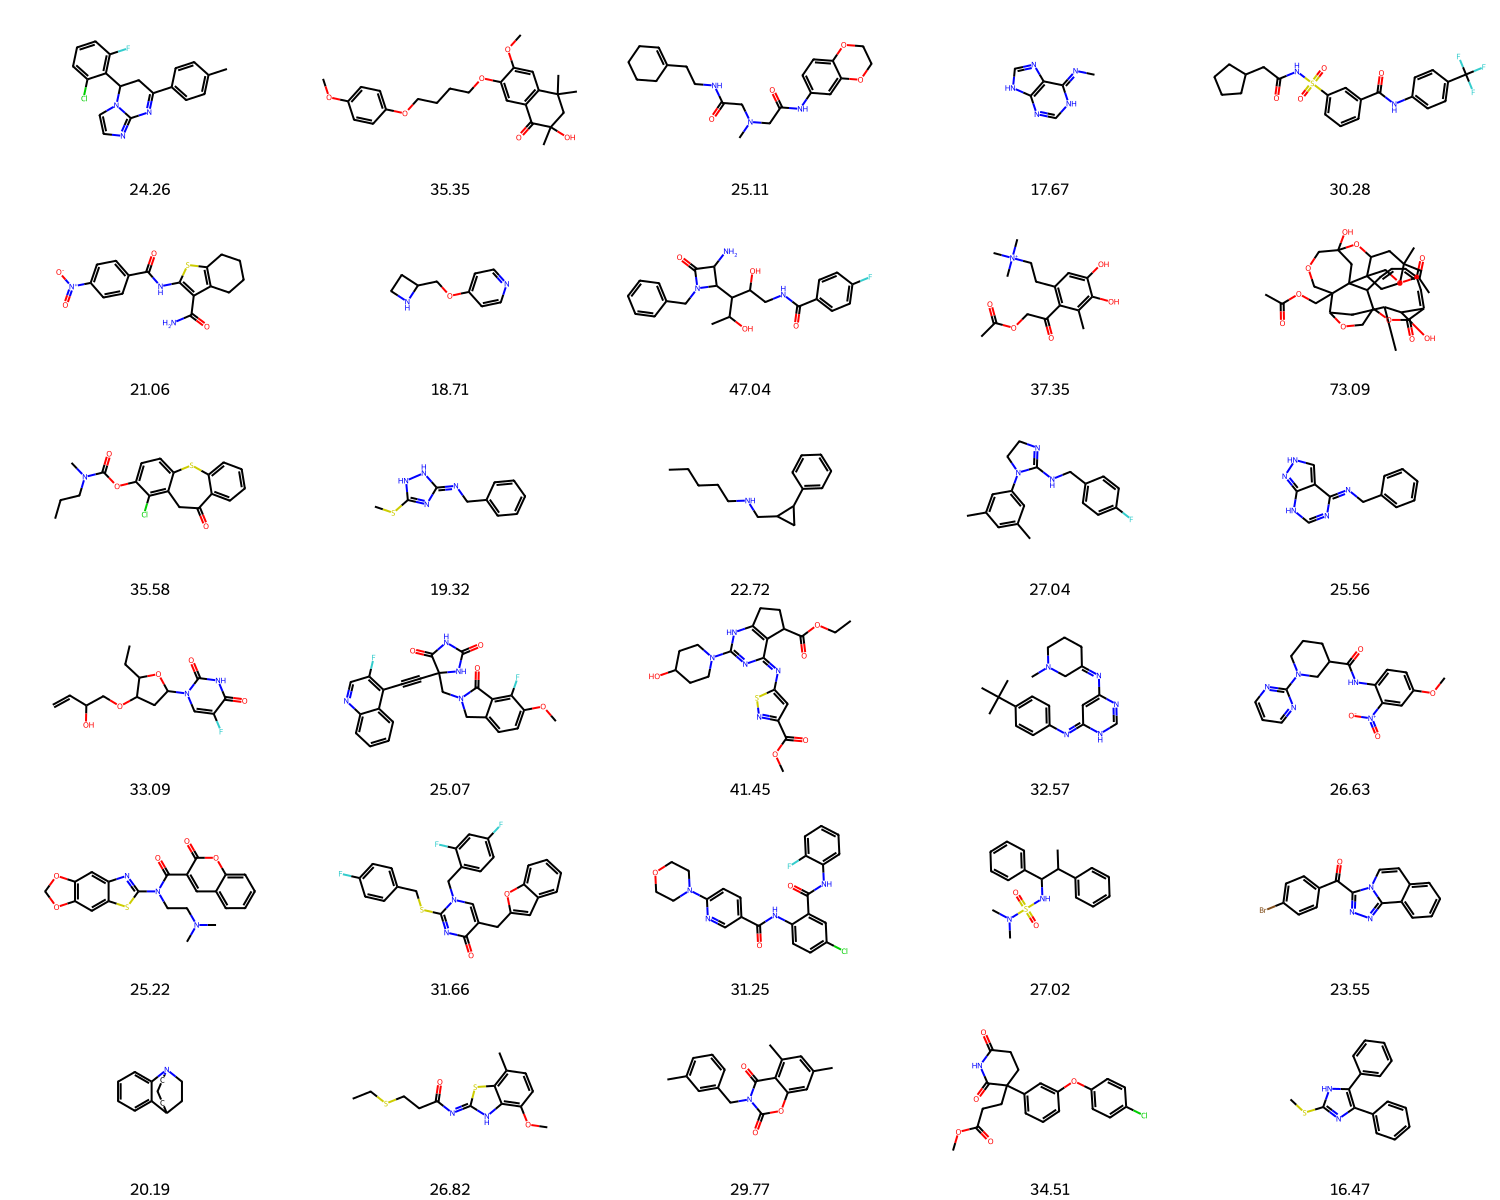

In [ ]:
from rdkit.Chem import PandasTools, Draw
df = pd.read_csv(f"{results}/random_sampling_{timestamp}.csv")
PandasTools.AddMoleculeColumnToFrame(df, smilesCol='SMILES', molCol='Mol')
Draw.MolsToGridImage(df.head(30).Mol.tolist(), molsPerRow=5, subImgSize=(300,200), legends=df.NLL.astype(str).tolist())

### mol2mol

In [ ]:
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")

mol2mol=f'''
# REINVENT4 TOML input example for sampling
run_type = "sampling"
device = "mps"  # set torch device e.g. "cpu". For macOS, use "mps"
json_out_config = "_sampling.json"  # write this TOML to JSON


[parameters]

# Uncomment one of the comment blocks below.  Each generator needs a model
# file and possibly a SMILES file with seed structures.

# Mol2Mol: find molecules similar to the provided molecules
model_file = '{mol2mol_high}'
smiles_file = "{input}/mol2mol.smi"  # 1 compound per line
sample_strategy = "beamsearch"  # multinomial or beamsearch (deterministic)
#temperature = 1.0 # temperature in multinomial sampling
#tb_logdir = "tb_logs"  # name of the TensorBoard logging directory

output_file = '{results}/mol2mol_high_{timestamp}.csv'  # sampled SMILES and NLL in CSV format

num_smiles = 200  # number of SMILES to be sampled, 1 per input SMILES
unique_molecules = true  # if true remove all duplicatesd canonicalize smiles
randomize_smiles = true # if true shuffle atoms in SMILES randomly
'''

toml_path = f"{wd}/toml/mol2mol_high.toml"

with open(toml_path, "w") as f:
    f.write(mol2mol)

# Run REINVENT4
subprocess.call([reinvent, '-l', f'{wd}/mol2mol.log', toml_path])


0

                                          smiles           ID
0               O=S(=O)(c1cccc2cnccc12)N1CCCNCC1  CHEMBL38380
1  COc1ccc(CN(CC(=O)NO)S(=O)(=O)c2ccc(OC)cc2)cc1  CHEMBL82783


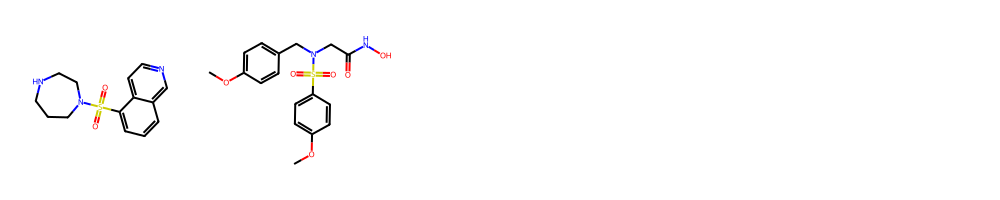

In [ ]:
df = pd.read_csv(f'{reinvent_dir}/configs/toml/mol2mol.smi', sep='\t', header=None, names=["smiles", "ID"], comment='#')
print(df.head(2))
Draw.MolsToGridImage([Chem.MolFromSmiles(smi) for smi in df.smiles][:20], molsPerRow=5)


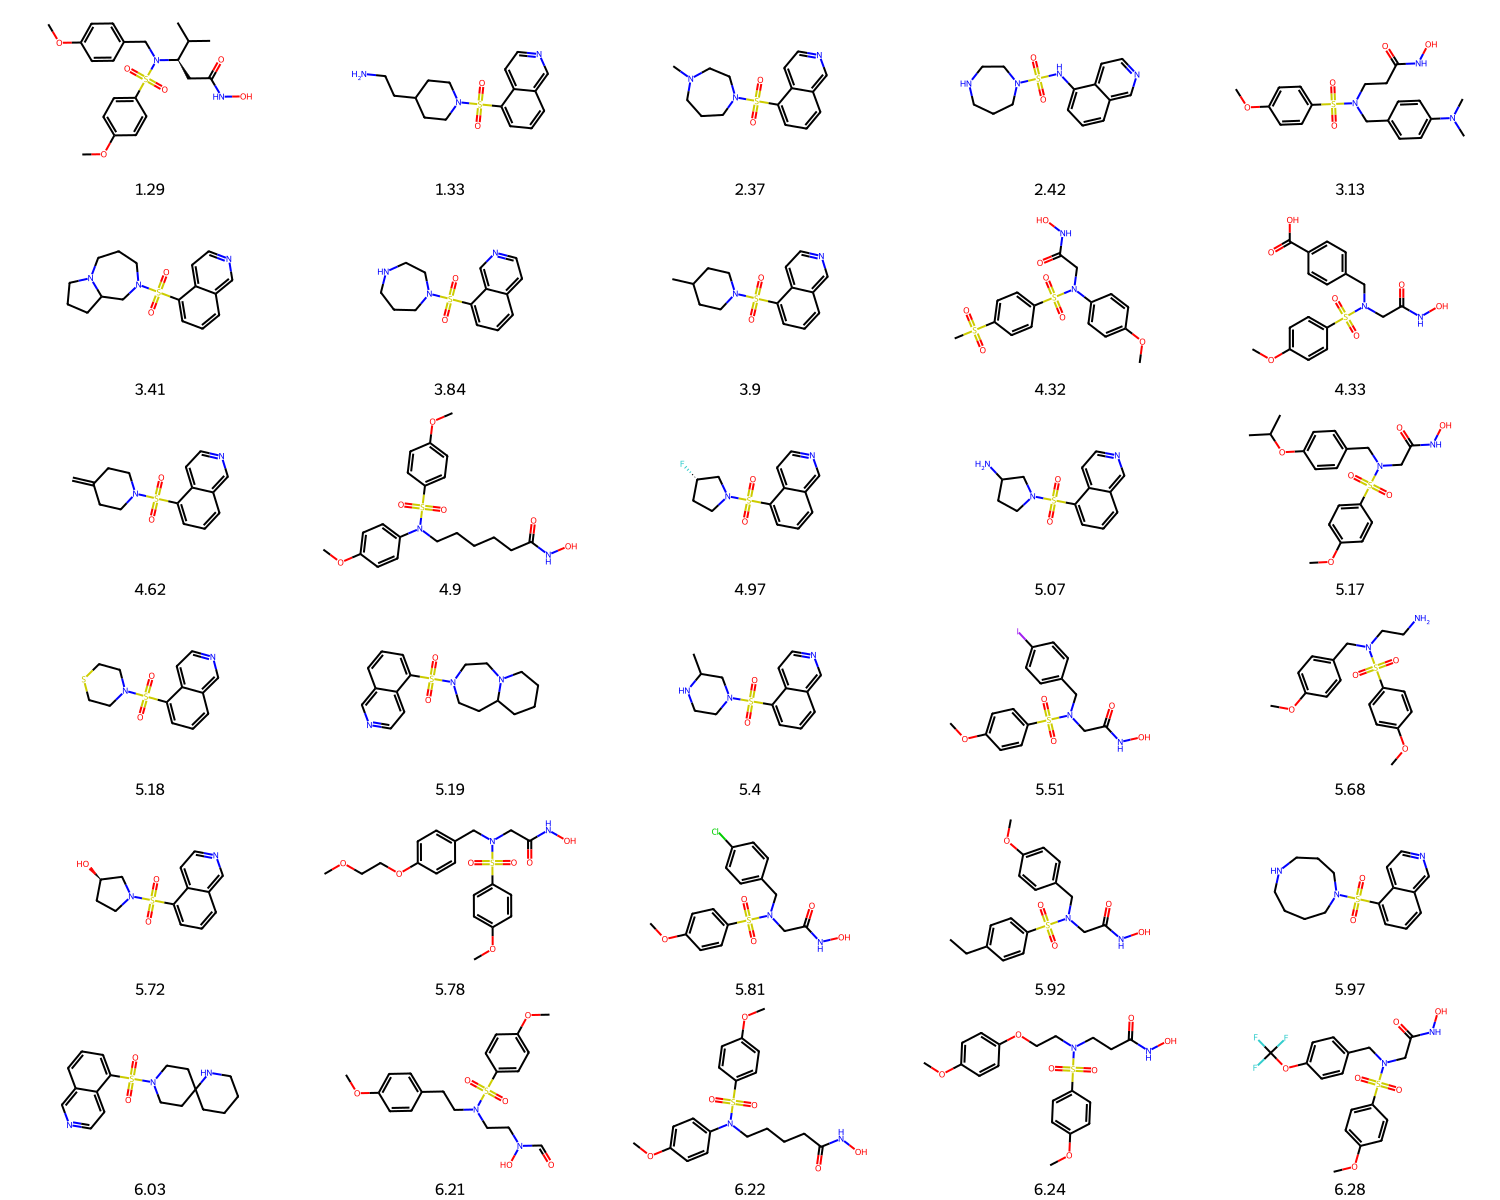

In [ ]:
from rdkit.Chem import PandasTools, Draw
df = pd.read_csv(f'{results}/mol2mol_high_{timestamp}.csv')
PandasTools.AddMoleculeColumnToFrame(df, smilesCol='SMILES', molCol='Mol')
Draw.MolsToGridImage(df.sample(30).Mol.tolist(), molsPerRow=5, subImgSize=(300,200), legends=df.NLL.astype(str).tolist())


### mmp

In [ ]:
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")

toml=f'''
# REINVENT4 TOML input example for sampling
run_type = "sampling"
device = "mps"  # set torch device e.g. "cpu". For macOS, use "mps"
json_out_config = "_sampling.json"  # write this TOML to JSON


[parameters]

# Uncomment one of the comment blocks below.  Each generator needs a model
# file and possibly a SMILES file with seed structures.

# Mol2Mol: find molecules similar to the provided molecules
model_file = '{mol2mol_mmp}'
smiles_file = "{input}/mol2mol.smi"  # 1 compound per line
sample_strategy = "beamsearch"  # multinomial or beamsearch (deterministic)
#temperature = 1.0 # temperature in multinomial sampling
#tb_logdir = "tb_logs"  # name of the TensorBoard logging directory

output_file = '{results}/mol2mol_mmp_{timestamp}.csv'  # sampled SMILES and NLL in CSV format

num_smiles = 200  # number of SMILES to be sampled, 1 per input SMILES
unique_molecules = true  # if true remove all duplicatesd canonicalize smiles
randomize_smiles = true # if true shuffle atoms in SMILES randomly
'''

toml_path = f"{wd}/toml/mol2mol_mmp.toml"

with open(toml_path, "w") as f:
    f.write(toml)

# Run REINVENT4
subprocess.call([reinvent, '-l', f'{wd}/mol2mol.log', toml_path])

from rdkit.Chem import PandasTools, Draw
df = pd.read_csv(f'{results}/mol2mol_mmp_{timestamp}.csv')
PandasTools.AddMoleculeColumnToFrame(df, smilesCol='SMILES', molCol='Mol')
Draw.MolsToGridImage(df.sample(30).Mol.tolist(), molsPerRow=5, subImgSize=(300,200), legends=df.NLL.astype(str).tolist())


0

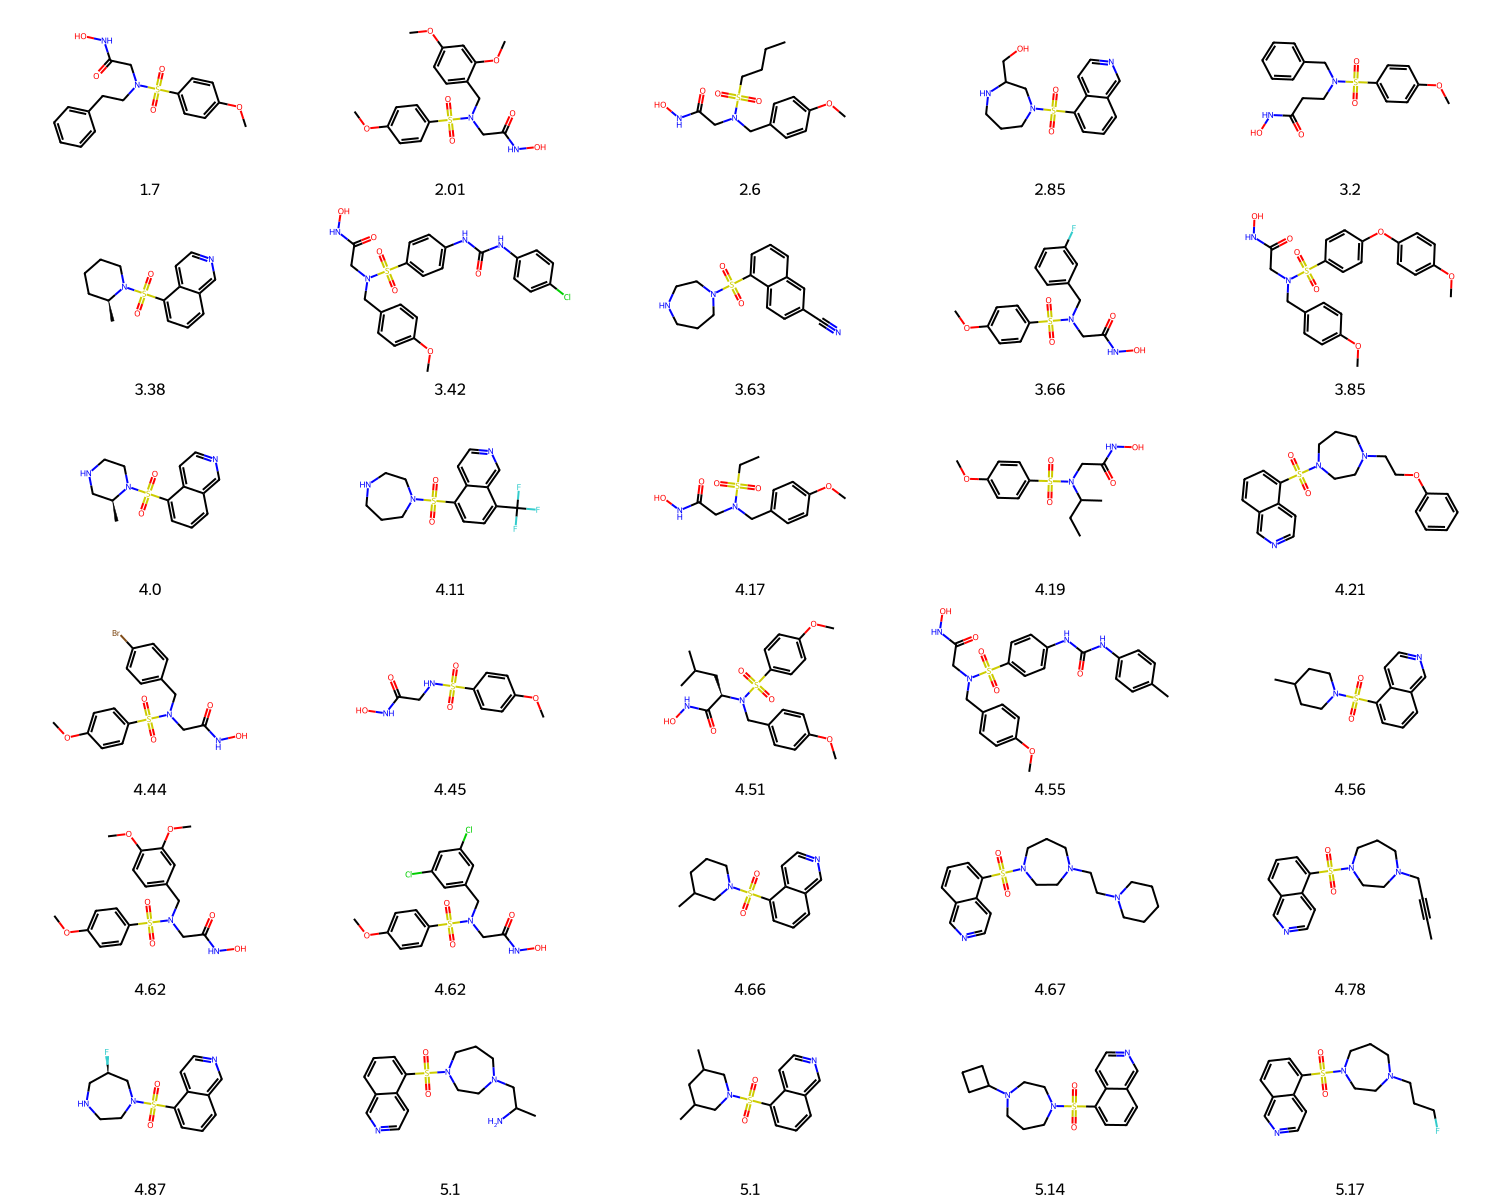

### scaffold

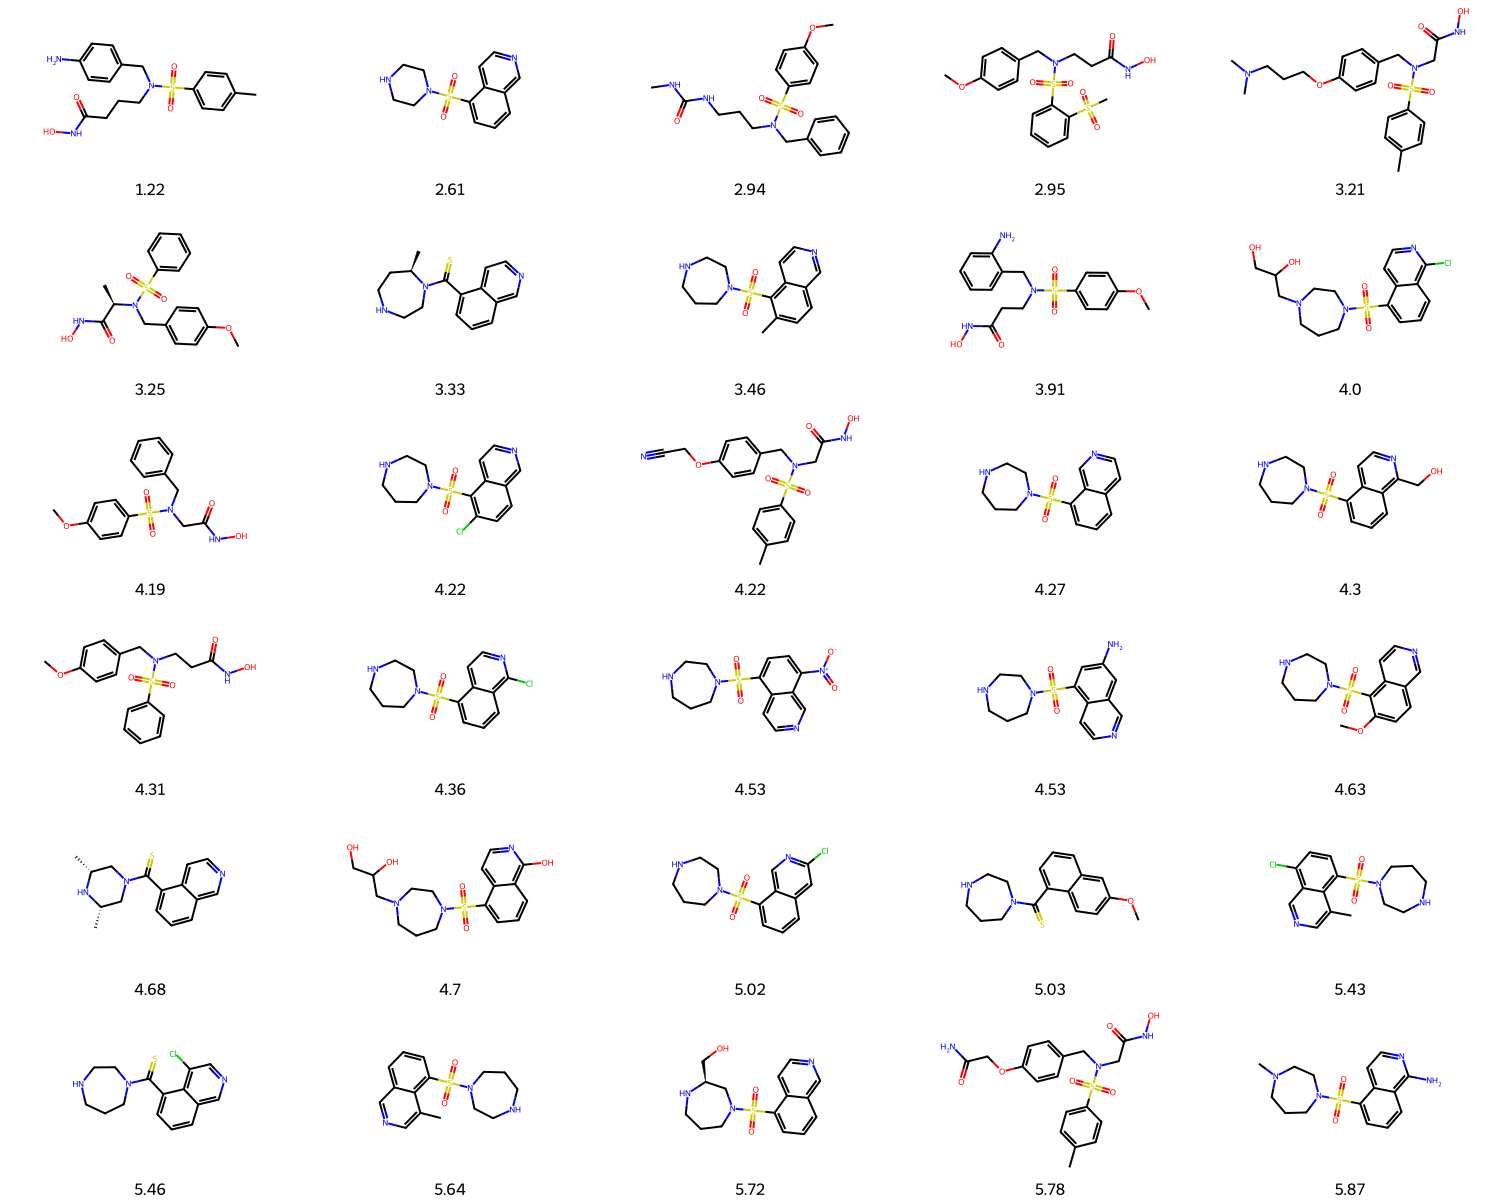

In [ ]:
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")

toml=f'''
# REINVENT4 TOML input example for sampling
run_type = "sampling"
device = "mps"  # set torch device e.g. "cpu". For macOS, use "mps"
json_out_config = "_sampling.json"  # write this TOML to JSON


[parameters]

# Uncomment one of the comment blocks below.  Each generator needs a model
# file and possibly a SMILES file with seed structures.

# Mol2Mol: find molecules similar to the provided molecules
model_file = '{mol2mol_scaffold}'
smiles_file = "{input}/mol2mol.smi"  # 1 compound per line
sample_strategy = "beamsearch"  # multinomial or beamsearch (deterministic)
#temperature = 1.0 # temperature in multinomial sampling
#tb_logdir = "tb_logs"  # name of the TensorBoard logging directory

output_file = '{results}/mol2mol_mmp_{timestamp}.csv'  # sampled SMILES and NLL in CSV format

num_smiles = 200  # number of SMILES to be sampled, 1 per input SMILES
unique_molecules = true  # if true remove all duplicatesd canonicalize smiles
randomize_smiles = true # if true shuffle atoms in SMILES randomly
'''

toml_path = f"{wd}/toml/mol2mol_scaffold.toml"

with open(toml_path, "w") as f:
    f.write(toml)

# Run REINVENT4
subprocess.call([reinvent, '-l', f'{wd}/mol2mol.log', toml_path])

from rdkit.Chem import PandasTools, Draw
df = pd.read_csv(f'{results}/mol2mol_mmp_{timestamp}.csv')
PandasTools.AddMoleculeColumnToFrame(df, smilesCol='SMILES', molCol='Mol')
Draw.MolsToGridImage(df.sample(30).Mol.tolist(), molsPerRow=5, subImgSize=(300,200), legends=df.NLL.astype(str).tolist())


### scaffold generic

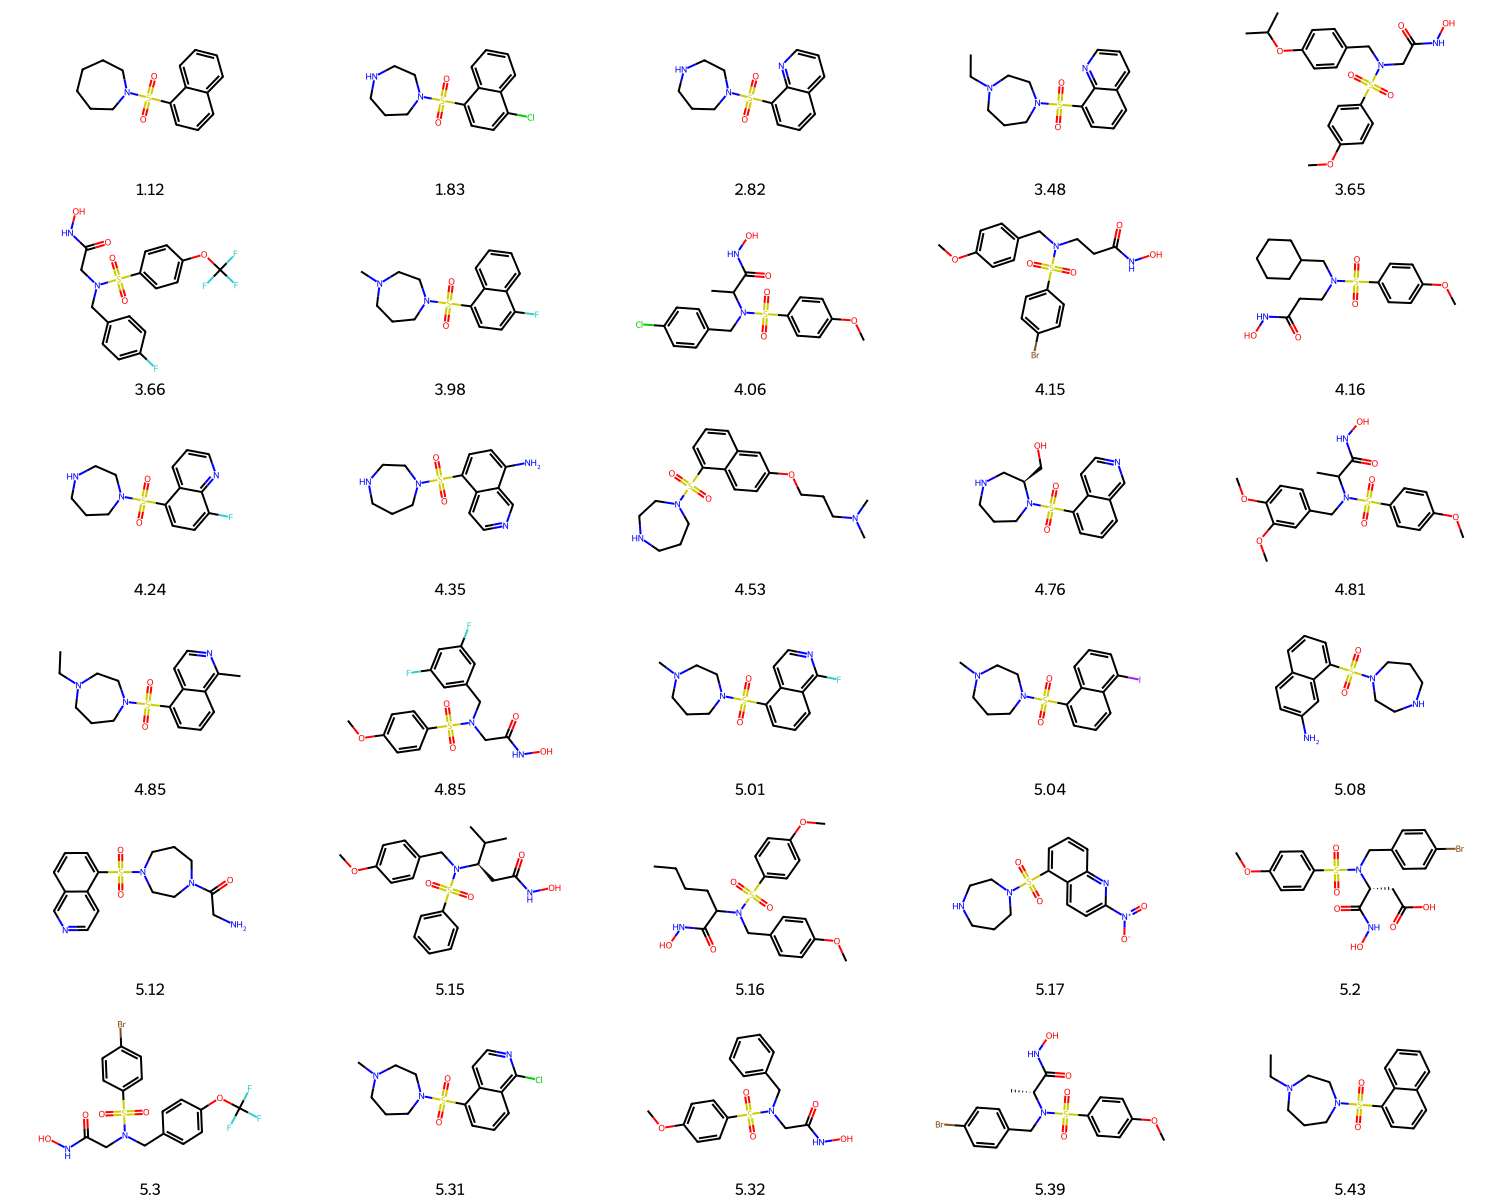

In [ ]:
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")

toml=f'''
# REINVENT4 TOML input example for sampling
run_type = "sampling"
device = "mps"  # set torch device e.g. "cpu". For macOS, use "mps"
json_out_config = "_sampling.json"  # write this TOML to JSON


[parameters]

# Uncomment one of the comment blocks below.  Each generator needs a model
# file and possibly a SMILES file with seed structures.

# Mol2Mol: find molecules similar to the provided molecules
model_file = '{mol2mol_scaffold_generic}'
smiles_file = "{input}/mol2mol.smi"  # 1 compound per line
sample_strategy = "beamsearch"  # multinomial or beamsearch (deterministic)
#temperature = 1.0 # temperature in multinomial sampling
#tb_logdir = "tb_logs"  # name of the TensorBoard logging directory

output_file = '{results}/mol2mol_scaffold_generic_{timestamp}.csv'  # sampled SMILES and NLL in CSV format

num_smiles = 200  # number of SMILES to be sampled, 1 per input SMILES
unique_molecules = true  # if true remove all duplicatesd canonicalize smiles
randomize_smiles = true # if true shuffle atoms in SMILES randomly
'''

toml_path = f"{wd}/toml/mol2mol_scaffold.toml"

with open(toml_path, "w") as f:
    f.write(toml)

# Run REINVENT4
subprocess.call([reinvent, '-l', f'{wd}/mol2mol.log', toml_path])

from rdkit.Chem import PandasTools, Draw
df = pd.read_csv(f'{results}/mol2mol_scaffold_generic_{timestamp}.csv')
PandasTools.AddMoleculeColumnToFrame(df, smilesCol='SMILES', molCol='Mol')
Draw.MolsToGridImage(df.sample(30).Mol.tolist(), molsPerRow=5, subImgSize=(300,200), legends=df.NLL.astype(str).tolist())
